# Optimización para portafolios de inversion

In [20]:
from qiskit.circuit.library import TwoLocal
from qiskit.result import QuasiDistribution
from qiskit_aer.primitives import Sampler
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA, SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_finance.data_providers import YahooDataProvider
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_finance.exceptions import QiskitFinanceError
from qiskit_optimization.translators import from_docplex_mp
from docplex.mp.model import Model

import numpy as np
import matplotlib.pyplot as plt
import datetime

### Obtención de datos

In [37]:
#Se define una funcion para visualizar mejor los resultados 
def print_result(result):

    print(
        f"Optimal: selection {result.x}, "
        f"value {result.fval:.4f}"
    )

    print("\n----------------- Full result ---------------------")
    print("selection\t\tvalue\t\tprobability")
    print("---------------------------------------------------")

    for sample in result.samples:

        x = sample.x
        value = sample.fval
        prob = sample.probability

        print(
            f"{x}\t"
            f"{value:.4f}\t\t"
            f"{prob:.4f}"
        )

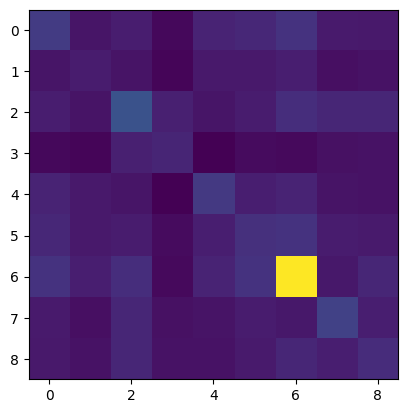

In [6]:
# plot sigma
plt.imshow(sigma, interpolation="nearest")
plt.show()

[*********************100%***********************]  9 of 9 completed


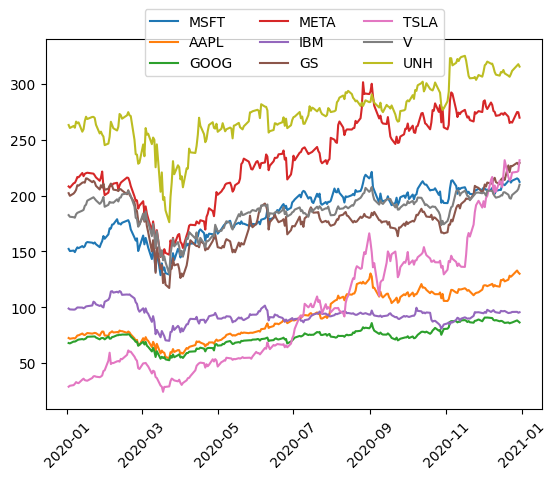

In [23]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

tickers = ["MSFT", "AAPL", "GOOG", "META", "IBM", "GS", "TSLA", "V", "UNH"]

raw = yf.download(
    tickers,
    start="2020-01-01",
    end="2020-12-31",
    auto_adjust=False
)

prices = raw["Adj Close"]

for ticker in tickers:
    plt.plot(prices[ticker], label=ticker)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=3)
plt.xticks(rotation=45)
plt.show()

In [24]:
returns = prices.pct_change().dropna()

mu = returns.mean().to_numpy()

sigma = returns.cov().to_numpy()

print("Vector de rendimientos esperados:")
print(mu)
#print(sigma)

Vector de rendimientos esperados:
[0.00276907 0.00125223 0.00104221 0.00019794 0.00145424 0.00171069
 0.0099507  0.0011853  0.00091724]


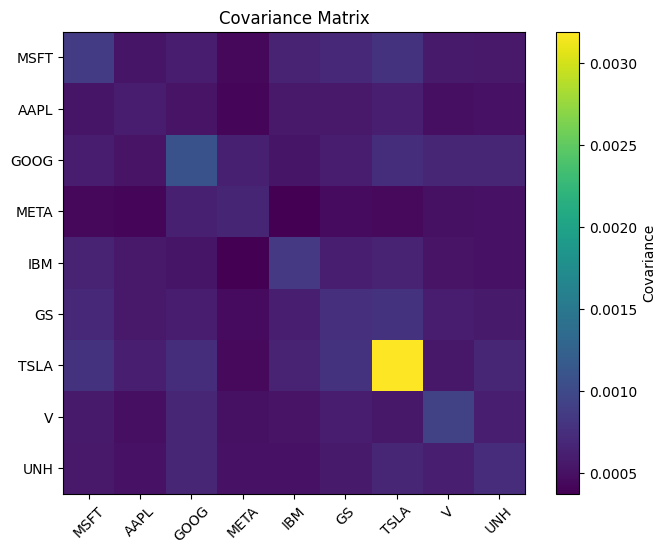

In [25]:
plt.figure(figsize=(8, 6))
plt.imshow(sigma, interpolation="nearest")
plt.colorbar(label="Covariance")

plt.xticks(range(len(tickers)), tickers, rotation=45)
plt.yticks(range(len(tickers)), tickers)

plt.title("Covariance Matrix")
plt.show()

In [26]:
# -------------------------------------------------
# 6. Create portfolio optimization problem
# -------------------------------------------------
q = 0.5
budget = 2
#penalty = num_assets

portfolio = PortfolioOptimization(
    expected_returns=mu,
    covariances=sigma,
    risk_factor=q,
    budget=2
)

# Convert to quadratic program (QUBO)
qp = portfolio.to_quadratic_program()

# Print optimization problem
print(qp.prettyprint())

Problem name: Portfolio optimization

Minimize
  0.00043421602692741263*x_0^2 + 0.000536570787457193*x_0*x_1
  + 0.0006031811872547039*x_0*x_2 + 0.0004388168414634251*x_0*x_3
  + 0.0006558942794699532*x_0*x_4 + 0.0006861880818213197*x_0*x_5
  + 0.0007862362932639328*x_0*x_6 + 0.0005813641377700188*x_0*x_7
  + 0.0005630236527183932*x_0*x_8 + 0.0002927133443756887*x_1^2
  + 0.0005268651573922451*x_1*x_2 + 0.0004108000562415136*x_1*x_3
  + 0.0005634002571648815*x_1*x_4 + 0.0005720632829401376*x_1*x_5
  + 0.0006122460442235982*x_1*x_6 + 0.0004920260204543075*x_1*x_7
  + 0.0005143100415476148*x_1*x_8 + 0.0005442292238352623*x_2^2
  + 0.000623428214740087*x_2*x_3 + 0.0005310397694303153*x_2*x_4
  + 0.0005918645825331958*x_2*x_5 + 0.0007386371210189684*x_2*x_6
  + 0.0006746503389864799*x_2*x_7 + 0.0006757061167887324*x_2*x_8
  + 0.0003334640611287811*x_3^2 + 0.0003748587943452395*x_3*x_4
  + 0.0004585850842089078*x_3*x_5 + 0.0004408562391605391*x_3*x_6
  + 0.0005025215556311176*x_3*x_7 + 0.00

### Classical solution

In [39]:
from qiskit_algorithms import NumPyMinimumEigensolver

exact = MinimumEigenOptimizer(
    NumPyMinimumEigensolver()
)

exact_result = exact.solve(qp)

#rint(exact_result)
print_result(result)

Optimal: selection [1. 0. 0. 0. 0. 0. 1. 0. 0.], value -0.0099

----------------- Full result ---------------------
selection		value		probability
---------------------------------------------------
[1. 0. 0. 0. 0. 0. 1. 0. 0.]	-0.0099		0.0000
[0. 0. 0. 0. 0. 1. 1. 0. 0.]	-0.0089		0.0000
[0. 0. 0. 0. 1. 0. 1. 0. 0.]	-0.0087		0.0000
[0. 1. 0. 0. 0. 0. 1. 0. 0.]	-0.0087		0.0000
[0. 0. 0. 0. 0. 0. 1. 1. 0.]	-0.0085		0.0000
[0. 0. 0. 0. 0. 0. 1. 0. 1.]	-0.0082		0.0000
[0. 0. 1. 0. 0. 0. 1. 0. 0.]	-0.0081		0.0000
[0. 0. 0. 1. 0. 0. 1. 0. 0.]	-0.0078		0.0000
[1. 0. 0. 0. 0. 1. 0. 0. 0.]	-0.0030		0.0000
[1. 1. 0. 0. 0. 0. 0. 0. 0.]	-0.0028		0.0001
[1. 0. 0. 0. 1. 0. 0. 0. 0.]	-0.0027		0.0000
[1. 0. 0. 0. 0. 0. 0. 1. 0.]	-0.0025		0.0000
[1. 0. 0. 0. 0. 0. 0. 0. 1.]	-0.0023		0.0000
[1. 0. 1. 0. 0. 0. 0. 0. 0.]	-0.0022		0.0000
[1. 0. 0. 1. 0. 0. 0. 0. 0.]	-0.0018		0.0000
[0. 0. 0. 0. 1. 1. 0. 0. 0.]	-0.0017		0.0000
[0. 1. 0. 0. 0. 1. 0. 0. 0.]	-0.0017		0.0001
[0. 0. 0. 0. 0. 1. 0. 1. 0.]	-0.0015	

### QAOA

In [38]:
from qiskit_aer.primitives import Sampler
shots = 1024

mes = QAOA(
    sampler=StatevectorSampler(),
    optimizer=COBYLA(),
    reps=1
)

meo = MinimumEigenOptimizer(mes)

result = meo.solve(qp)

#print(result)
print_result(result)

/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/florencio/jupyter_project/quno/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Optimal: selection [1. 0. 0. 0. 0. 0. 1. 0. 0.], value -0.0099

----------------- Full result ---------------------
selection		value		probability
---------------------------------------------------
[1. 0. 0. 0. 0. 0. 1. 0. 0.]	-0.0099		0.0000
[0. 0. 0. 0. 0. 1. 1. 0. 0.]	-0.0089		0.0000
[0. 0. 0. 0. 1. 0. 1. 0. 0.]	-0.0087		0.0000
[0. 1. 0. 0. 0. 0. 1. 0. 0.]	-0.0087		0.0000
[0. 0. 0. 0. 0. 0. 1. 1. 0.]	-0.0085		0.0000
[0. 0. 0. 0. 0. 0. 1. 0. 1.]	-0.0082		0.0000
[0. 0. 1. 0. 0. 0. 1. 0. 0.]	-0.0081		0.0000
[0. 0. 0. 1. 0. 0. 1. 0. 0.]	-0.0078		0.0000
[1. 0. 0. 0. 0. 1. 0. 0. 0.]	-0.0030		0.0000
[1. 1. 0. 0. 0. 0. 0. 0. 0.]	-0.0028		0.0001
[1. 0. 0. 0. 1. 0. 0. 0. 0.]	-0.0027		0.0000
[1. 0. 0. 0. 0. 0. 0. 1. 0.]	-0.0025		0.0000
[1. 0. 0. 0. 0. 0. 0. 0. 1.]	-0.0023		0.0000
[1. 0. 1. 0. 0. 0. 0. 0. 0.]	-0.0022		0.0000
[1. 0. 0. 1. 0. 0. 0. 0. 0.]	-0.0018		0.0000
[0. 0. 0. 0. 1. 1. 0. 0. 0.]	-0.0017		0.0000
[0. 1. 0. 0. 0. 1. 0. 0. 0.]	-0.0017		0.0001
[0. 0. 0. 0. 0. 1. 0. 1. 0.]	-0.0015	